#  Q-learning

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Саттон Р.	С.,	Барто Э. Дж. Обучение с подкреплением: Введение. 2-е изд.
* https://gymnasium.farama.org/tutorials/training_agents/blackjack_tutorial/
* https://en.wikipedia.org/wiki/Q-learning
* https://www.baeldung.com/cs/epsilon-greedy-q-learning
* https://pythonprogramming.net/q-learning-reinforcement-learning-python-tutorial/
* https://www.datacamp.com/tutorial/introduction-q-learning-beginner-tutorial
* https://rubikscode.net/2021/07/20/introduction-to-double-q-learning/
* https://gymnasium.farama.org/api/wrappers/misc_wrappers/#gymnasium.wrappers.RecordVideo

## Задачи для совместного разбора

1\. Рассмотрите понятие Q-функции, ее применение для формирования политики агента и способов ее создания.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Обучите агента для игры в блэкджек (окружение `Blackjack-v1`), используя алгоритм Q-learning. Для создания таблицы Q-функции выясните размеры пространства состояния игры и количество возможных действий игрока и выведите эти значения на экран. Во время обучения несколько раз вычислите статистику за `print_every` последних эпизодов: количество выигранных и проигранных сессий. После завершения обучения визуализируйте полученные данные. Изучите, как выглядит Q-функция (в каких состояниях игрок будет брать карту, в каких - нет). Cыграйте `N=10000` игр, применяя стратегию, выведенную из обученной Q-функции, посчитайте и выведите на экран долю выигранных игр.

Cтратегия для выбора действия:
$$a_{t+1}(s_t) = argmax_aQ(s_t, a)$$

Правило обновления Q-функции: 

![q-learning](https://wikimedia.org/api/rest_v1/media/math/render/svg/d247db9eaad4bd343e7882ec546bf3847ebd36d8)

- [ ] Проверено на семинаре

In [35]:
from dataclasses import dataclass

@dataclass
class Config:
    discount: float = 0.95
    lr: float = 0.005
    n_episodes: float = 1_000_000
    print_every: int = 100_000

In [65]:
import gymnasium as gym
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
class Agent:
    def __init__(self, env: gym.Env, config: Config) -> None:
        self.env = env
        self.cfg = config
        self._create_q_table()
        self.stats={'wins':0,'losses':0,'draws':0}
        self.actions=[0,1]
        self.win_rates=[]
    
    def _create_q_table(self, init_method='zeros'):
        if init_method == 'zeros':
            self.q_table = np.zeros((32, 11, 2, 2))
        elif init_method == 'random':
            self.q_table = np.random.uniform(low=-1, high=1, size=(32, 11, 2, 2))
        elif init_method == 'positive':
            self.q_table = np.full((32, 11, 2, 2), 1)

    def get_action(self, state: np.ndarray) -> int:
        player_sum, dealer_card, usable_ace = state
        return np.argmax(self.q_table[player_sum, dealer_card, int(usable_ace)])
        pass

    def update_q_table(self, state: np.ndarray | tuple, new_state: np.ndarray | tuple, reward: float, action: int, done: bool) -> None:
        player_sum, dealer_card, usable_ace = state
        new_player_sum, new_dealer_card, new_usable_ace = new_state
        old_value = self.q_table[player_sum, dealer_card, int(usable_ace), action]
        future_value = 0 if done else np.max(self.q_table[new_player_sum, new_dealer_card, int(new_usable_ace)])
        self.q_table[player_sum, dealer_card, int(usable_ace), action] += self.cfg.lr * (
            reward + self.cfg.discount * future_value - old_value
        )
        
    def run_episode(self) -> float:
        done = False
        state, info = self.env.reset()
        while not done:
            action = self.get_action(state)
            new_state, reward, terminated, truncated, info = self.env.step(action)
            done = terminated or truncated
            self.update_q_table(state, new_state, reward, action, done) 
            state = new_state 
            if done:
                return reward
            
        
    def train(self):
        ep_rewards = []
        for ep in range(1, self.cfg.n_episodes + 1):
            reward = self.run_episode()
            ep_rewards.append(reward)
            
            if reward > 0:
                self.stats["wins"] += 1
            elif reward < 0:
                self.stats["losses"] += 1
            else:
                self.stats["draws"] += 1
            
            if ep % self.cfg.print_every == 0:
                print(f"Episode {ep}: Wins: {self.stats['wins']}, Losses: {self.stats['losses']}, Draws: {self.stats['draws']}")
                win_rate = self.stats["wins"] / ep
                self.win_rates.append(win_rate)
        return ep_rewards
        
    def play(self, n_games: int = 10_000):
        wins, losses, draws = 0, 0, 0
        for _ in range(n_games):
            state, _ = self.env.reset()
            done = False
            while not done:
                action = np.argmax(self.q_table[state[0], state[1], int(state[2])])
                new_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                state = new_state
            if reward > 0:
                wins += 1
            elif reward < 0:
                losses += 1
            else:
                draws += 1
        win_rate = wins / n_games
        print(f"After {n_games} games: Wins: {wins}, Losses: {losses}, Draws: {draws}, Win rate: {win_rate:.2f}")
        return win_rate

    def visualize_q_function(self):
        
        player_sums = range(3, 22)
        dealer_cards = range(1, 11)
        usable_aces = [0, 1]
        
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        titles = ["No Usable Ace", "Usable Ace"]
        
        for idx, usable_ace in enumerate(usable_aces):
            heatmap = np.zeros((len(player_sums), len(dealer_cards)))
            for i, player_sum in enumerate(player_sums):
                for j, dealer_card in enumerate(dealer_cards):
                    action = np.argmax(self.q_table[player_sum, dealer_card, usable_ace])
                    heatmap[i, j] = action
            
            sns.heatmap(
                heatmap, annot=True, cmap="coolwarm", cbar=False,
                xticklabels=dealer_cards, yticklabels=player_sums, ax=axes[idx]
            )
            axes[idx].set_title(titles[idx])
            axes[idx].set_xlabel("Dealer's Showing Card")
            axes[idx].set_ylabel("Player's Sum")
        
        plt.tight_layout()
        plt.show()

env = gym.make("Blackjack-v1",natural=True, sab=False)

config = Config()
agent = Agent(env, config)
ep_rewards = agent.train()
final_win_rate = agent.play(n_games=10_000)

Episode 5000: Wins: 1988, Losses: 2626, Draws: 386
Episode 10000: Wins: 4123, Losses: 5056, Draws: 821
Episode 15000: Wins: 6249, Losses: 7501, Draws: 1250
Episode 20000: Wins: 8242, Losses: 10099, Draws: 1659
Episode 25000: Wins: 10363, Losses: 12568, Draws: 2069
Episode 30000: Wins: 12414, Losses: 15101, Draws: 2485
Episode 35000: Wins: 14554, Losses: 17573, Draws: 2873
Episode 40000: Wins: 16616, Losses: 20081, Draws: 3303
Episode 45000: Wins: 18654, Losses: 22605, Draws: 3741
Episode 50000: Wins: 20660, Losses: 25137, Draws: 4203
Episode 55000: Wins: 22740, Losses: 27640, Draws: 4620
Episode 60000: Wins: 24768, Losses: 30169, Draws: 5063
Episode 65000: Wins: 26881, Losses: 32649, Draws: 5470
Episode 70000: Wins: 28975, Losses: 35141, Draws: 5884
Episode 75000: Wins: 31101, Losses: 37578, Draws: 6321
Episode 80000: Wins: 33269, Losses: 39965, Draws: 6766
Episode 85000: Wins: 35334, Losses: 42431, Draws: 7235
Episode 90000: Wins: 37445, Losses: 44895, Draws: 7660
Episode 95000: Wins:

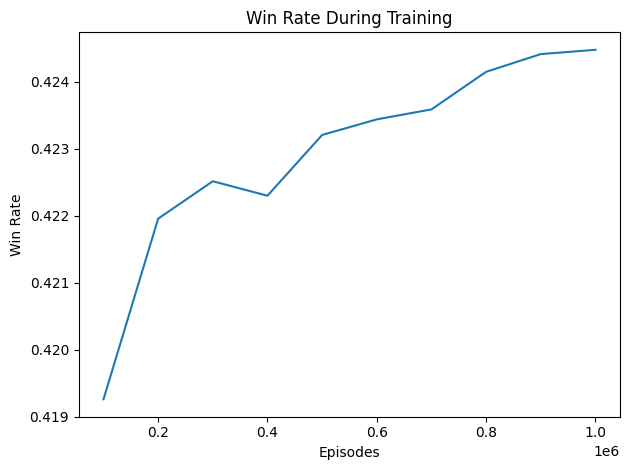

In [47]:
plt.plot(range(config.print_every, config.n_episodes + 1, config.print_every), agent.win_rates)
plt.title("Win Rate During Training")
plt.xlabel("Episodes")
plt.ylabel("Win Rate")

plt.tight_layout()
plt.show()

In [48]:
print(f'Пространство состояний : {agent.q_table.shape}')

Пространство состояний : (32, 11, 2, 2)


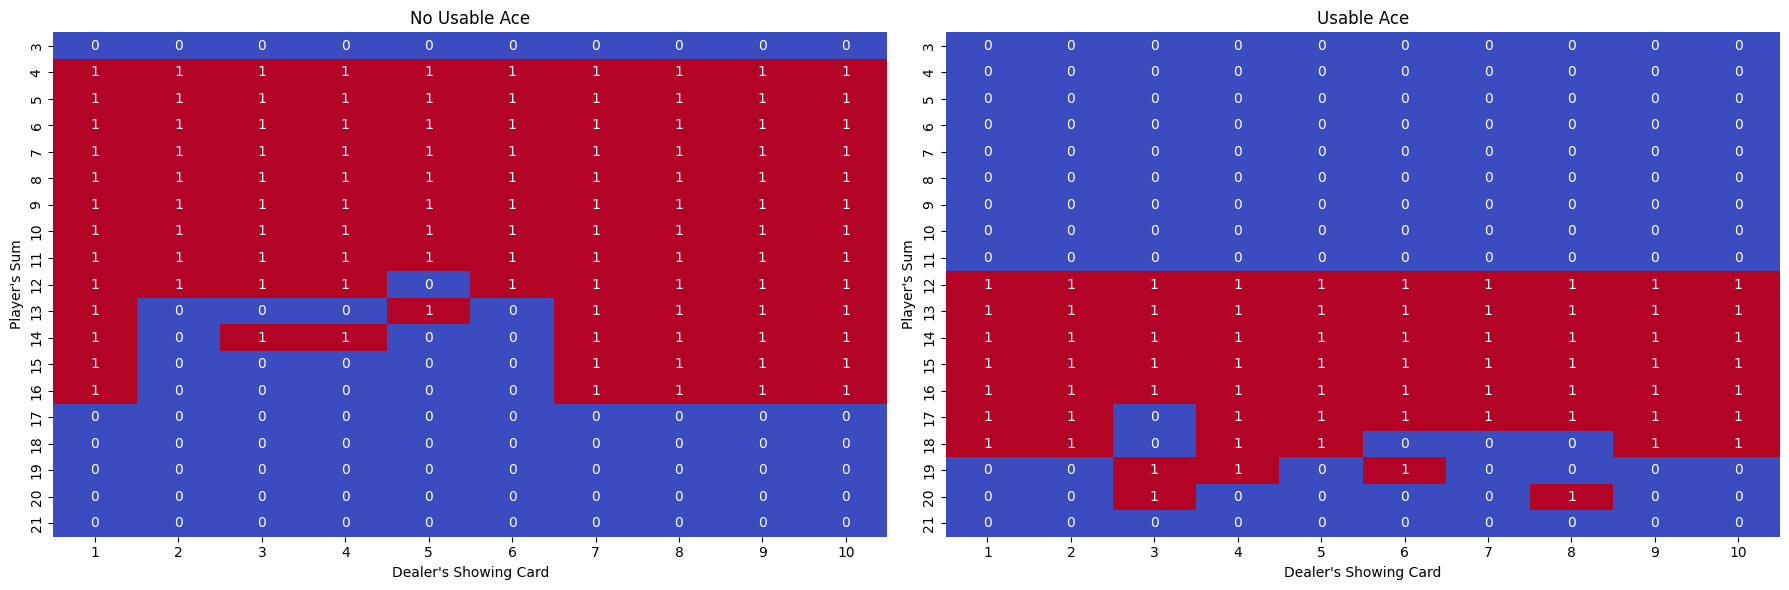

In [49]:
agent.visualize_q_function()


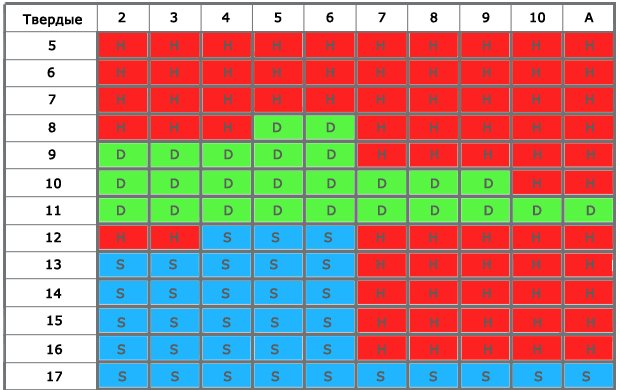

In [216]:
 from IPython.display import HTML
import base64
with open("bj_table.jpg", "rb") as img_file:
    image_base64 = base64.b64encode(img_file.read()).decode('utf-8')
HTML(f'<img src="data:image/png;base64,{image_base64}" width="640">')


<p class="task" id="2"></p>

2\. Повторите решение предыдущей задачи, используя алгоритм $\epsilon$-greedy Q-learning. Исследуйте, как гиперпараметры и способ инициализации значений Q-функции влияют на результат.

Cтратегия для выбора действия:
1. Сгенерировать число $p$ из $U(0, 1)$;
2. Если $p < \epsilon$, то выбрать действие случайным образом;
3. В противном случае $a_{t+1}(s_t) = argmax_aQ(s_t, a)$.

Правило обновления Q-функции: 
![q-learning](https://wikimedia.org/api/rest_v1/media/math/render/svg/d247db9eaad4bd343e7882ec546bf3847ebd36d8)

- [ ] Проверено на семинаре

In [50]:
from dataclasses import dataclass

@dataclass
class Config:
    discount: float = 0.95
    lr: float = 0.005
    n_episodes: float = 100_000
    epsilon: float = 1.0
    final_epsilon: float = 0.3
    print_every: int = 5000

In [72]:
class QGreedyAgent(Agent):
    def get_action(self, state: tuple) -> int:
        player_sum, dealer_card, usable_ace = state
        if np.random.uniform(0, 1) < self.cfg.epsilon:
            return np.random.choice(self.actions)
        return np.argmax(self.q_table[player_sum, dealer_card, int(usable_ace)])
    def train(self, verbose=0):
        ep_rewards = []
        avg_rewards = []
        epsilon_decay = (self.cfg.epsilon - self.cfg.final_epsilon) / self.cfg.n_episodes
        
        for ep in range(1, self.cfg.n_episodes + 1):
            self.cfg.epsilon = max(self.cfg.final_epsilon, self.cfg.epsilon - epsilon_decay)
            
            reward = self.run_episode()
            ep_rewards.append(reward)
            
            if reward > 0:
                self.stats["wins"] += 1
            elif reward < 0:
                self.stats["losses"] += 1
            else:
                self.stats["draws"] += 1
            
            if ep % self.cfg.print_every == 0:
                avg_last_rewards = np.mean(ep_rewards[-self.cfg.print_every:])
                avg_rewards.append(avg_last_rewards)
                win_rate = self.stats["wins"] / ep
                self.win_rates.append(win_rate)
                
                if verbose > 0:
                    print(f"Episode {ep}: Wins: {self.stats['wins']}, Losses: {self.stats['losses']}, "
                          f"Draws: {self.stats['draws']}, Win Rate: {win_rate:.2f}, "
                          f"Avg Reward (last {self.cfg.print_every}): {avg_last_rewards:.2f}")
        
        if verbose <= 0:
            avg_rewards = [np.mean(ep_rewards)]
        return ep_rewards, avg_rewards



In [74]:
env = gym.make("Blackjack-v1",natural=True, sab=False)

config = Config()
agent = QGreedyAgent(env, config)
ep_rewards = agent.train(verbose=1)
final_win_rate = agent.play(n_games=10_000)

Episode 5000: Wins: 1397, Losses: 3394, Draws: 209, Win Rate: 0.28, Avg Reward (last 5000): -0.39
Episode 10000: Wins: 2830, Losses: 6705, Draws: 465, Win Rate: 0.28, Avg Reward (last 5000): -0.36
Episode 15000: Wins: 4289, Losses: 9995, Draws: 716, Win Rate: 0.29, Avg Reward (last 5000): -0.35
Episode 20000: Wins: 5787, Losses: 13238, Draws: 975, Win Rate: 0.29, Avg Reward (last 5000): -0.34
Episode 25000: Wins: 7303, Losses: 16499, Draws: 1198, Win Rate: 0.29, Avg Reward (last 5000): -0.34
Episode 30000: Wins: 8894, Losses: 19652, Draws: 1454, Win Rate: 0.30, Avg Reward (last 5000): -0.30
Episode 35000: Wins: 10461, Losses: 22820, Draws: 1719, Win Rate: 0.30, Avg Reward (last 5000): -0.31
Episode 40000: Wins: 12026, Losses: 25993, Draws: 1981, Win Rate: 0.30, Avg Reward (last 5000): -0.31
Episode 45000: Wins: 13616, Losses: 29109, Draws: 2275, Win Rate: 0.30, Avg Reward (last 5000): -0.29
Episode 50000: Wins: 15258, Losses: 32192, Draws: 2550, Win Rate: 0.31, Avg Reward (last 5000): 

In [76]:
from dataclasses import dataclass
import gymnasium as gym
import numpy as np

def run_experiment(agent_class, env, config, init_method, epsilon, final_epsilon):
    cfg = Config(
        discount=config.discount,
        lr=config.lr,
        n_episodes=config.n_episodes,
        print_every=config.print_every,
        epsilon=epsilon,
        final_epsilon=final_epsilon,
    )
    
    agent = agent_class(env, cfg)
    agent._create_q_table(init_method=init_method)
    print(f"\nTraining with init={init_method}, epsilon={epsilon}, final_epsilon={final_epsilon}")
    ep_rewards, avg_rewards = agent.train()
    final_win_rate = agent.play(n_games=10_000)
    return final_win_rate, avg_rewards


env = gym.make("Blackjack-v1", natural=True, sab=False)
config = Config()

init_methods = ["zeros", "random", "positive"]
epsilons = [1.0, 0.7,0]
final_epsilons = [1,0.5,0]

results = {}
for init in init_methods:
    for eps in epsilons:
        for final_eps in final_epsilons:
            key = f"init={init}, eps={eps}, final_eps={final_eps}"
            final_win_rate, avg_rewards = run_experiment(QGreedyAgent, env, config, init, eps, final_eps)
            results[key] = final_win_rate

print("\nFinal Win Rates:")
for key, value in results.items():
    print(f"{key}: Win rate: {value:.2f}")



Training with init=zeros, epsilon=1.0, final_epsilon=1
After 10000 games: Wins: 4296, Losses: 4804, Draws: 900, Win rate: 0.43

Training with init=zeros, epsilon=1.0, final_epsilon=0.5
After 10000 games: Wins: 4317, Losses: 4762, Draws: 921, Win rate: 0.43

Training with init=zeros, epsilon=1.0, final_epsilon=0
After 10000 games: Wins: 4258, Losses: 4804, Draws: 938, Win rate: 0.43

Training with init=zeros, epsilon=0.7, final_epsilon=1
After 10000 games: Wins: 4344, Losses: 4784, Draws: 872, Win rate: 0.43

Training with init=zeros, epsilon=0.7, final_epsilon=0.5
After 10000 games: Wins: 4295, Losses: 4730, Draws: 975, Win rate: 0.43

Training with init=zeros, epsilon=0.7, final_epsilon=0
After 10000 games: Wins: 4216, Losses: 4890, Draws: 894, Win rate: 0.42

Training with init=zeros, epsilon=0, final_epsilon=1
After 10000 games: Wins: 4339, Losses: 4821, Draws: 840, Win rate: 0.43

Training with init=zeros, epsilon=0, final_epsilon=0.5
After 10000 games: Wins: 4411, Losses: 4676, D

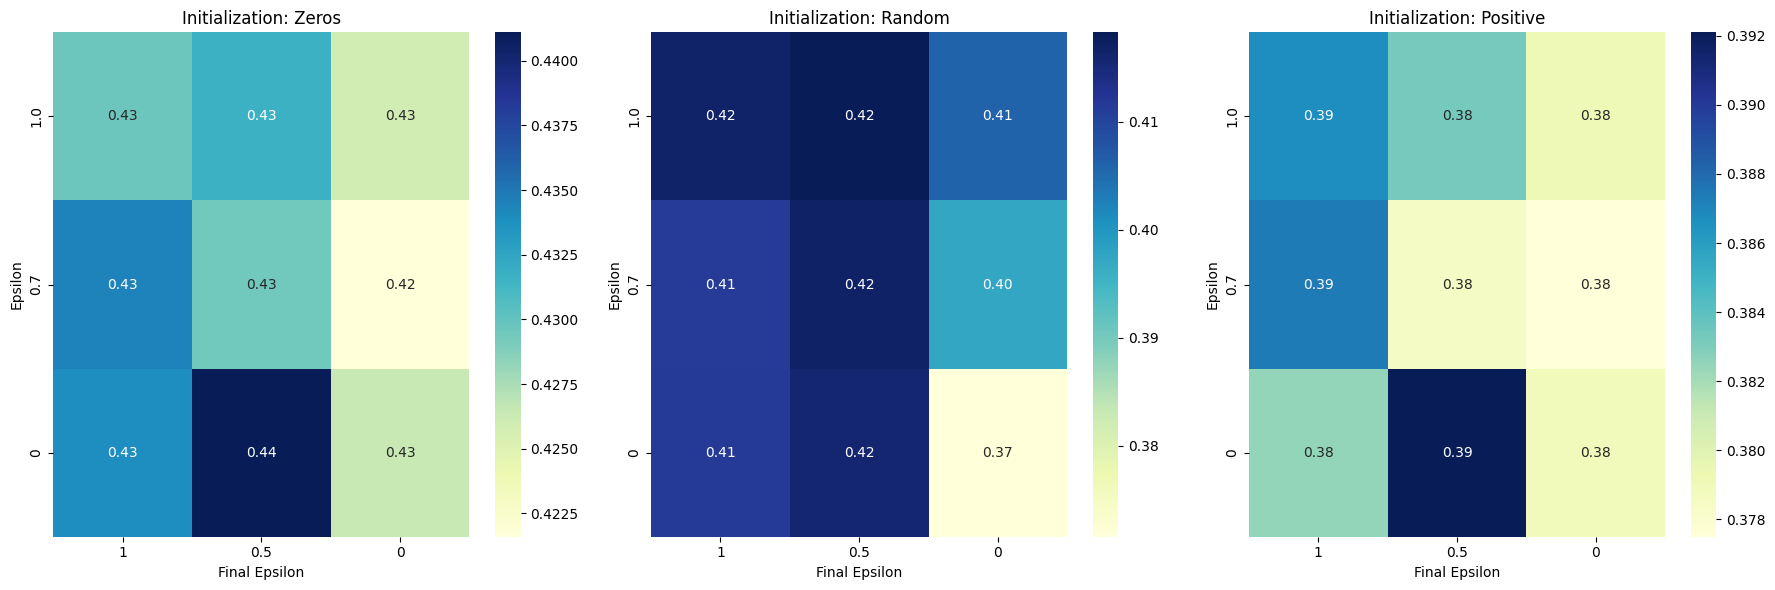

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

init_methods = ["zeros", "random", "positive"]
epsilons = [1.0, 0.7, 0]
final_epsilons = [1, 0.5, 0]

heatmap_data = {init: np.zeros((len(epsilons), len(final_epsilons))) for init in init_methods}

for i, eps in enumerate(epsilons):
    for j, final_eps in enumerate(final_epsilons):
        for init in init_methods:
            key = f"init={init}, eps={eps}, final_eps={final_eps}"
            heatmap_data[init][i, j] = results[key]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ["Initialization: Zeros", "Initialization: Random", "Initialization: Positive"]

for idx, init in enumerate(init_methods):
    sns.heatmap(
        heatmap_data[init],
        annot=True,
        cmap="YlGnBu",
        xticklabels=final_epsilons,
        yticklabels=epsilons,
        cbar=True,
        ax=axes[idx],
        fmt=".2f"
    )
    axes[idx].set_title(titles[idx])
    axes[idx].set_xlabel("Final Epsilon")
    axes[idx].set_ylabel("Epsilon")

plt.tight_layout()
plt.show()


<p class="task" id="3"></p>

3\. Повторите решение задачи 1, используя алгоритм double Q-learning. 

Cтратегия для выбора действия:
1. Сгенерировать число $p$ из $U(0, 1)$;
2. Если $p < \epsilon$, то выбрать действие случайным образом;
3. В противном случае $a_{t+1}(s_t) = argmax_a\left((Q^A_t + Q^B_t)(s_t, a))\right) $.

Правило обновления Q-функции: 
$$
Q^A_{t+1}(s_{t}, a_{t}) = Q^A_{t}(s_{t}, a_{t}) + \alpha_{t}(s_{t}, a_{t}) \left(r_{t} + \gamma Q^B_{t}\left(s_{t+1}, {arg~max}_{a} Q^A_t(s_{t+1}, a)\right) - Q^A_{t}(s_{t}, a_{t})\right)
$$

$$
Q^B_{t+1}(s_{t}, a_{t}) = Q^B_{t}(s_{t}, a_{t}) + \alpha_{t}(s_{t}, a_{t}) \left(r_{t} + \gamma Q^A_{t}\left(s_{t+1}, {arg~max}_{a} Q^B_t(s_{t+1}, a)\right) - Q^B_{t}(s_{t}, a_{t})\right)
$$


- [ ] Проверено на семинаре

In [78]:
class DoubleQAgent(Agent):
    def __init__(self, env: gym.Env, config: Config) -> None:
        super().__init__(env, config)
        self.q_table_A = np.zeros((32, 11, 2, 2))
        self.q_table_B = np.zeros((32, 11, 2, 2))
    
    def get_action(self, state: tuple) -> int:
        player_sum, dealer_card, usable_ace = state
        q_sum = self.q_table_A[player_sum, dealer_card, usable_ace] + self.q_table_B[player_sum, dealer_card, usable_ace]
        return np.argmax(q_sum)
    
    def update_q_table(self, state: tuple, new_state: tuple, reward: float, action: int, done: bool) -> None:
        player_sum, dealer_card, usable_ace = state
        new_player_sum, new_dealer_card, new_usable_ace = new_state
        
        if np.random.rand() < 0.5:
            best_next_action = np.argmax(self.q_table_A[new_player_sum, new_dealer_card, new_usable_ace])
            target = reward + (0 if done else self.cfg.discount * self.q_table_B[new_player_sum, new_dealer_card, new_usable_ace, best_next_action])
            self.q_table_A[player_sum, dealer_card, usable_ace, action] += self.cfg.lr * (
                target - self.q_table_A[player_sum, dealer_card, usable_ace, action]
            )
        else:
            best_next_action = np.argmax(self.q_table_B[new_player_sum, new_dealer_card, new_usable_ace])
            target = reward + (0 if done else self.cfg.discount * self.q_table_A[new_player_sum, new_dealer_card, new_usable_ace, best_next_action])
            self.q_table_B[player_sum, dealer_card, usable_ace, action] += self.cfg.lr * (
                target - self.q_table_B[player_sum, dealer_card, usable_ace, action]
            )

    def play(self, n_games: int = 10_000):
        wins, losses, draws = 0, 0, 0
        for _ in range(n_games):
            state, _ = self.env.reset()
            done = False
            while not done:
                action = self.get_action(state)
                new_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
                state = new_state
            if reward > 0:
                wins += 1
            elif reward < 0:
                losses += 1
            else:
                draws += 1
        win_rate = wins / n_games
        print(f"After {n_games} games: Wins: {wins}, Losses: {losses}, Draws: {draws}, Win rate: {win_rate:.2f}")
        return win_rate


In [80]:
double_q_agent = DoubleQAgent(env, config)
ep_rewards = double_q_agent.train()
final_win_rate = double_q_agent.play(n_games=10_000)

Episode 5000: Wins: 2030, Losses: 2595, Draws: 375
Episode 10000: Wins: 4053, Losses: 5197, Draws: 750
Episode 15000: Wins: 6126, Losses: 7754, Draws: 1120
Episode 20000: Wins: 8229, Losses: 10244, Draws: 1527
Episode 25000: Wins: 10331, Losses: 12720, Draws: 1949
Episode 30000: Wins: 12431, Losses: 15211, Draws: 2358
Episode 35000: Wins: 14538, Losses: 17710, Draws: 2752
Episode 40000: Wins: 16627, Losses: 20185, Draws: 3188
Episode 45000: Wins: 18708, Losses: 22696, Draws: 3596
Episode 50000: Wins: 20803, Losses: 25195, Draws: 4002
Episode 55000: Wins: 22867, Losses: 27702, Draws: 4431
Episode 60000: Wins: 24967, Losses: 30186, Draws: 4847
Episode 65000: Wins: 27091, Losses: 32644, Draws: 5265
Episode 70000: Wins: 29180, Losses: 35114, Draws: 5706
Episode 75000: Wins: 31224, Losses: 37606, Draws: 6170
Episode 80000: Wins: 33344, Losses: 40073, Draws: 6583
Episode 85000: Wins: 35426, Losses: 42578, Draws: 6996
Episode 90000: Wins: 37544, Losses: 45015, Draws: 7441
Episode 95000: Wins:

<p class="task" id="4"></p>

4\. Обучите агента для управления машиной (окружение `MountainCar-v0`) при помощи любого из рассмотренных вариантов алгоритма Q-learning. Для перехода от непрерывного пространства состояний к конечному разбейте пространство состояний на окна (количество окон выберите сами). Для определения минимальных и максимальных значений координат воспользуйтесь [информацией об окружении](https://gymnasium.farama.org/environments/classic_control/mountain_car/#observation-space). Во время обучения несколько раз вычислите среднее значение наград за эпизод за несколько последних эпизодов и количество успешных сессий за последние эпизоды. После завершения обучения визуализируйте полученные данные.

Сделайте несколько промежуточных видео с записью работы агента во время обучения. 

- [ ] Проверено на семинаре

In [199]:
import numpy as np
import gymnasium as gym
from tqdm import tqdm
import matplotlib.pyplot as plt

class MountainCarAgent:
    def __init__(self, env, n_bins=(20, 20), lr=0.1, discount=0.99, epsilon=1.0, final_epsilon=0.1, n_episodes=50000, print_every=100):
        self.env = env
        self.n_bins = n_bins
        self.lr = lr
        self.discount = discount
        self.epsilon = epsilon
        self.final_epsilon = final_epsilon
        self.n_episodes = n_episodes
        self.print_every = print_every
        self.epsilon_decay = (epsilon - final_epsilon) / n_episodes
        self.avg_rewards = []
        self.avg_steps = []

        self.state_bounds = list(zip(self.env.observation_space.low, self.env.observation_space.high))
        self.q_table = np.random.uniform(low=0.01, high=0.2, size=(*n_bins, self.env.action_space.n))

        self.rewards = []
        self.successes = []
        self.steps_per_episode = []

    def discretize_state(self, state):
        ratios = [(state[i] - self.state_bounds[i][0]) / (self.state_bounds[i][1] - self.state_bounds[i][0]) for i in range(len(state))]
        bins = [int(np.clip(ratio * self.n_bins[i], 0, self.n_bins[i] - 1)) for i, ratio in enumerate(ratios)]
        return tuple(bins)

    def get_action(self, state):
        if np.random.uniform(0, 1) < self.epsilon:
            return self.env.action_space.sample()
        return np.argmax(self.q_table[state])

    def train(self, video_every=1000):
        exploration_end = int(0.7 * self.n_episodes)
        epsilon_decay = self.epsilon / exploration_end
        env_video = gym.wrappers.RecordVideo(self.env, video_folder="videos", episode_trigger=lambda x: x % video_every == 0)

        for ep in tqdm(range(1, self.n_episodes + 1)):
            if ep <= exploration_end:
                self.epsilon = max(0.0, self.epsilon - epsilon_decay)
            else:
                self.epsilon = 0.0

            state, _ = env_video.reset()
            state = self.discretize_state(state)
            done = False
            total_reward = 0
            steps = 0
            reached_goal = False

            while not done:
                action = self.get_action(state)
                next_state, reward, terminated, truncated, _ = env_video.step(action)
                next_state = self.discretize_state(next_state)
                done = terminated or truncated

                if self.env.unwrapped.state[0] >= 0.5:
                    reached_goal = True
                    reward = 0

                best_next_action = np.argmax(self.q_table[next_state])
                self.q_table[state][action] += self.lr * (
                    reward + self.discount * self.q_table[next_state][best_next_action] - self.q_table[state][action]
                )

                state = next_state
                total_reward += reward
                steps += 1

            self.rewards.append(total_reward)
            self.steps_per_episode.append(steps)

            self.successes.append(1 if reached_goal else 0)

            if ep % self.print_every == 0:
                avg_reward = np.mean(self.rewards[-self.print_every:])
                success_rate = np.sum(self.successes[-self.print_every:]) / self.print_every
                avg_steps = np.mean(self.steps_per_episode[-self.print_every:])
                print(f"Episode {ep}: Avg Reward: {avg_reward:.2f}, Success Rate: {success_rate:.4f}, Avg Steps: {avg_steps:.2f}, Epsilon: {self.epsilon:.2f}")
                self.avg_rewards.append(avg_reward)
                self.avg_steps.append(avg_steps)

    def visualize(self):
        plt.figure(figsize=(18, 6))

        plt.subplot(1, 3, 1)
        plt.plot(self.avg_rewards)
        plt.title("Average Rewards per Episode")
        plt.xlabel(f"Episodes x{self.print_every}")
        plt.ylabel("Average Reward")

        plt.subplot(1, 3, 2)
        success_rates = np.convolve(self.successes, np.ones(self.print_every) / self.print_every, mode='valid')
        plt.plot(success_rates)
        plt.title("Success Rate")
        plt.xlabel("Episodes")
        plt.ylabel("Success Rate")

        plt.subplot(1, 3, 3)
        plt.plot(self.avg_steps)
        plt.title("Average Steps per Episode")
        plt.xlabel(f"Episodes (x{self.print_every})")
        plt.ylabel("Average Steps")

        plt.tight_layout()
        plt.show()


 10%|███████▍                                                                  | 10043/100000 [00:36<05:16, 284.66it/s]

Episode 10000: Avg Reward: -200.00, Success Rate: 0.0000, Avg Steps: 200.00, Epsilon: 0.86


 20%|██████████████▊                                                           | 20042/100000 [01:11<04:39, 285.77it/s]

Episode 20000: Avg Reward: -200.00, Success Rate: 0.0000, Avg Steps: 200.00, Epsilon: 0.71


 30%|██████████████████████▏                                                   | 30029/100000 [01:47<04:09, 280.83it/s]

...

Episode 80000: Avg Reward: -115.50, Success Rate: 1.0000, Avg Steps: 116.50, Epsilon: 0.00


 90%|██████████████████████████████████████████████████████████████████▋       | 90057/100000 [04:27<00:19, 514.62it/s]

Episode 90000: Avg Reward: -111.70, Success Rate: 1.0000, Avg Steps: 112.70, Epsilon: 0.00


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [04:46<00:00, 348.87it/s]


Episode 100000: Avg Reward: -111.64, Success Rate: 1.0000, Avg Steps: 112.64, Epsilon: 0.00


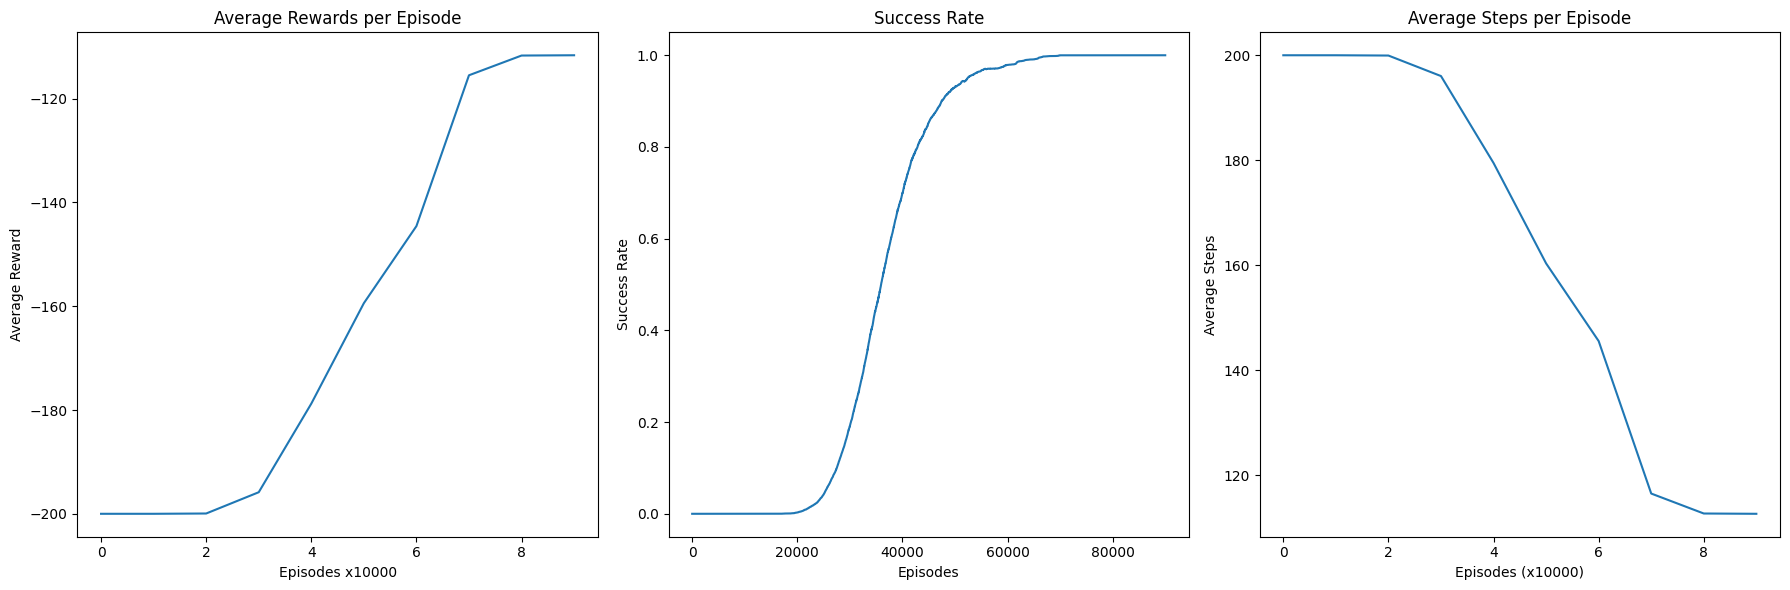

In [200]:
# Создание среды с поддержкой рендера
env = gym.make("MountainCar-v0", render_mode="rgb_array")

# Запуск обучения с видео
agent = MountainCarAgent(env, n_bins=(40,40), lr=0.081, discount=1, epsilon=1, final_epsilon=0.1, n_episodes=100_000, print_every=10_000)
agent.train(video_every=25_000)
agent.visualize()

In [219]:
from IPython.display import HTML
def pv(video_path,ep):
    print(f'Эпизод {ep}')
    with open(video_path, "rb") as video_file:
        video_base64 = base64.b64encode(video_file.read()).decode('utf-8')
    
    return HTML(f"""
    <video width="640" height="360" autoplay loop controls>
      <source src="data:video/mp4;base64,{video_base64}" type="video/mp4">
      Your browser does not support the video tag.
    </video>
    """)
pv("Videos/rl-video-episode-25000.mp4",25000)

Эпизод 25000


In [220]:
pv("Videos/rl-video-episode-50000.mp4",50000)

Эпизод 50000


In [221]:
pv("Videos/rl-video-episode-75000.mp4",75000)

Эпизод 75000


## Обратная связь
- [ ] Хочу получить обратную связь по решению